In [4]:
!pip install lightning-utilities
!pip install torchmetrics --no-deps

In [5]:
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import v2
from torchvision import models
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision.transforms.functional import to_pil_image
from torchmetrics import MeanMetric, Accuracy
from torchmetrics import ConfusionMatrix, Accuracy, Precision, Recall, F1Score

In [6]:
device = "cuda" if torch.cuda.is_available() \
          else "mps" if torch.mps.is_available() \
          else "cpu"
print("Device:", device)

Device: cuda


In [7]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [8]:
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/daphn3
/kaggle/input/datasets/daphn3/dfuc2021
/kaggle/input/datasets/daphn3/dfuc2021/DFU
/kaggle/input/datasets/daphn3/dfuc2021/DFU/DFUC2021_test
/kaggle/input/datasets/daphn3/dfuc2021/DFU/DFUC2021_train
/kaggle/input/datasets/daphn3/dfuc2021/DFU/DFUC2021_train/images


In [9]:
for root, dirs, files in os.walk("/kaggle/input/datasets/daphn3/dfuc2021/DFU"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/kaggle/input/datasets/daphn3/dfuc2021/DFU/DFUC2021_train/train.csv


In [10]:
DATA_DIR = "/kaggle/input/datasets/daphn3/dfuc2021/DFU"

train_csv = os.path.join(DATA_DIR, "DFUC2021_train", "train.csv")
train_image_dir = os.path.join(DATA_DIR, "DFUC2021_train", "images")
test_image_dir = os.path.join(DATA_DIR, "DFUC2021_test")

In [11]:
print(train_csv)
print(os.path.exists(train_csv))

print(train_image_dir)
print(os.path.exists(train_image_dir))

print(test_image_dir)
print(os.path.exists(test_image_dir))

/kaggle/input/datasets/daphn3/dfuc2021/DFU/DFUC2021_train/train.csv
True
/kaggle/input/datasets/daphn3/dfuc2021/DFU/DFUC2021_train/images
True
/kaggle/input/datasets/daphn3/dfuc2021/DFU/DFUC2021_test
True


In [12]:
train_df = pd.read_csv(train_csv)

train_df.head()

,image,none,infection,ischaemia,both
0,301000.jpg,1.0,0.0,0.0,0.0
1,301001.jpg,1.0,0.0,0.0,0.0
2,301002.jpg,0.0,1.0,0.0,0.0
3,301003.jpg,0.0,1.0,0.0,0.0
4,301004.jpg,0.0,1.0,0.0,0.0


In [13]:
label_cols = ["none", "infection", "ischaemia", "both"]
class_names = ["none", "infection", "ischaemia", "both"]

In [14]:
labelled_df = train_df[train_df[label_cols].notna().any(axis=1)].copy()
unlabelled_df = train_df[train_df[label_cols].isna().all(axis=1)].copy()

In [15]:
labelled_df["label"] = labelled_df[label_cols].values.argmax(axis=1)

In [16]:
print("Labelled:", len(labelled_df))
print("Unlabelled:", len(unlabelled_df))
print(labelled_df["label"].value_counts().sort_index())

Labelled: 5955
Unlabelled: 3994
label
0    2552
1    2555
2     227
3     621
Name: count, dtype: int64


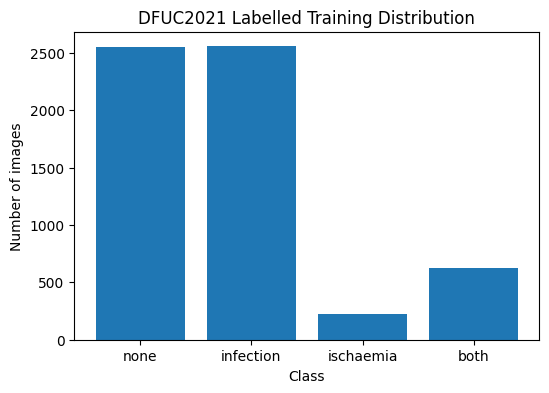

In [17]:
counts = labelled_df["label"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(class_names, counts)
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("DFUC2021 Labelled Training Distribution")
plt.show()

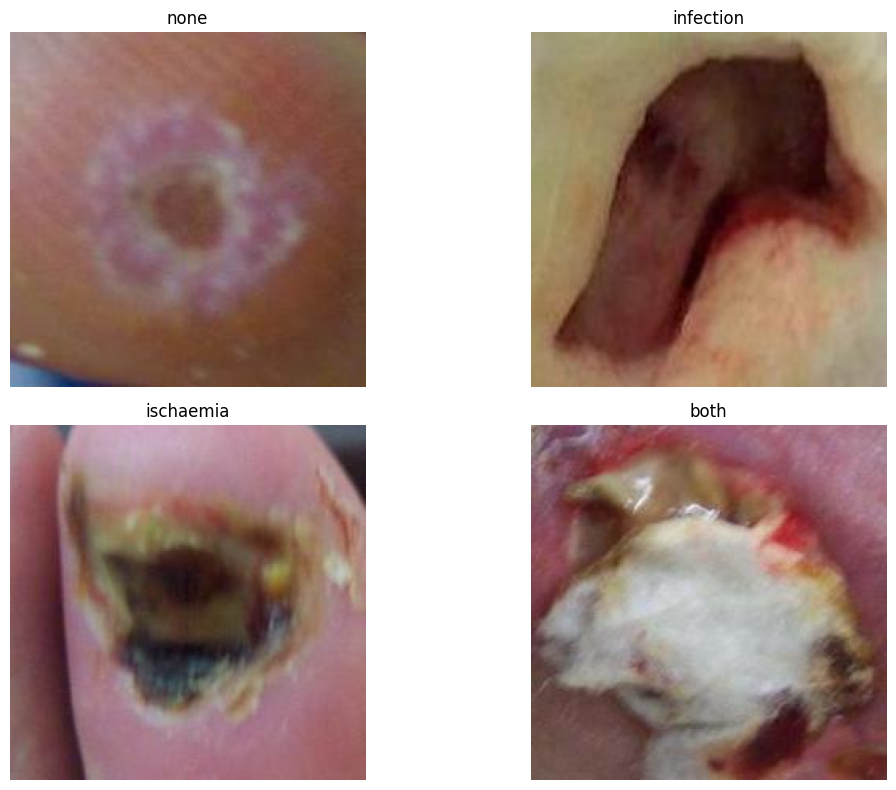

In [18]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(class_names):
    sample_row = labelled_df[labelled_df["label"] == i].sample(1, random_state=42).iloc[0]
    image_path = os.path.join(train_image_dir, sample_row["image"])

    img = Image.open(image_path).convert("RGB")

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
sizes = []

for img_name in train_df["image"].sample(200, random_state=42):
    img_path = os.path.join(train_image_dir, img_name)
    img = Image.open(img_path)
    sizes.append(img.size)

sizes[:10]

[(224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224)]

In [20]:
from sklearn.model_selection import train_test_split

train_split_df, val_df = train_test_split(
    labelled_df,
    test_size=0.10,
    random_state=seed,
    stratify=labelled_df["label"])

In [21]:
def show_distribution(df, name):
    print(f"\n{name}")
    print(df["label"].value_counts().sort_index())

show_distribution(train_split_df, "Train")
show_distribution(val_df, "Validation")



Train
label
0    2297
1    2299
2     204
3     559
Name: count, dtype: int64

Validation
label
0    255
1    256
2     23
3     62
Name: count, dtype: int64


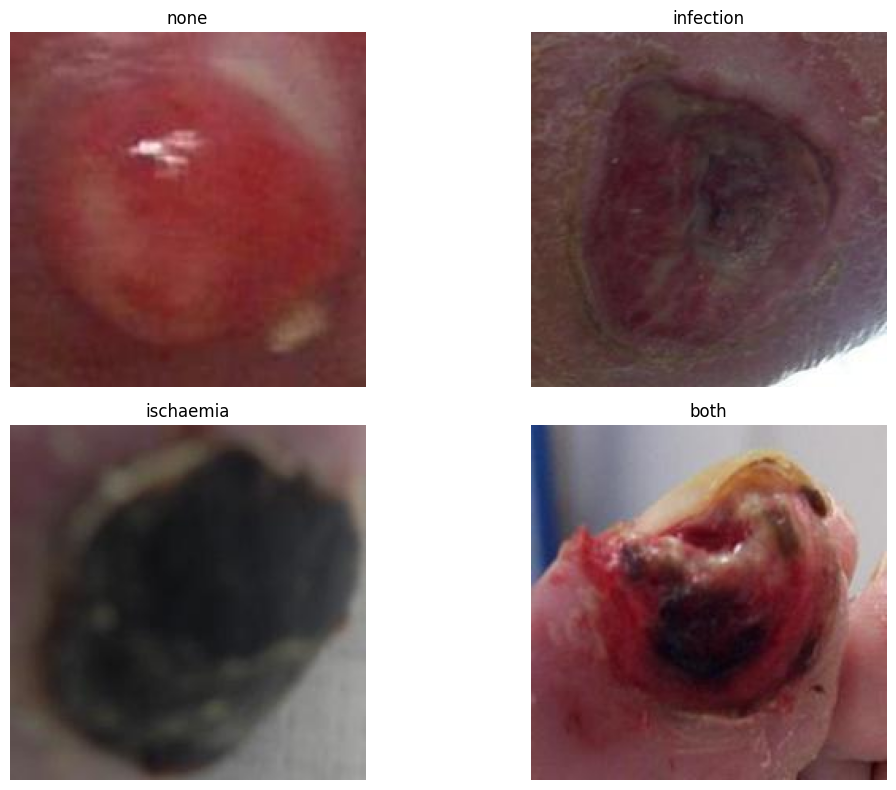

In [22]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(class_names):
    sample_row = train_split_df[train_split_df["label"] == i].sample(1, random_state=42).iloc[0]
    image_path = os.path.join(train_image_dir, sample_row["image"])

    img = Image.open(image_path).convert("RGB")

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
train_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=20),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


test_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [24]:
class DFUDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = os.path.join(self.image_dir, row["image"])
        image = Image.open(image_path).convert("RGB")

        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [25]:
train_dataset = DFUDataset(train_split_df, train_image_dir, transform=train_transform)

image, label = train_dataset[0]

print(image.shape)
print(label)
print(class_names[label])

torch.Size([3, 224, 224])
0
none


In [26]:
train_dataset = DFUDataset(
    train_split_df,
    train_image_dir,
    transform=train_transform
)

val_dataset = DFUDataset(
    val_df,
    train_image_dir,
    transform=test_transform
)

In [27]:
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [28]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([16, 3, 224, 224])
torch.Size([16])


In [29]:
print(labels)

tensor([1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 3, 2, 1, 3])


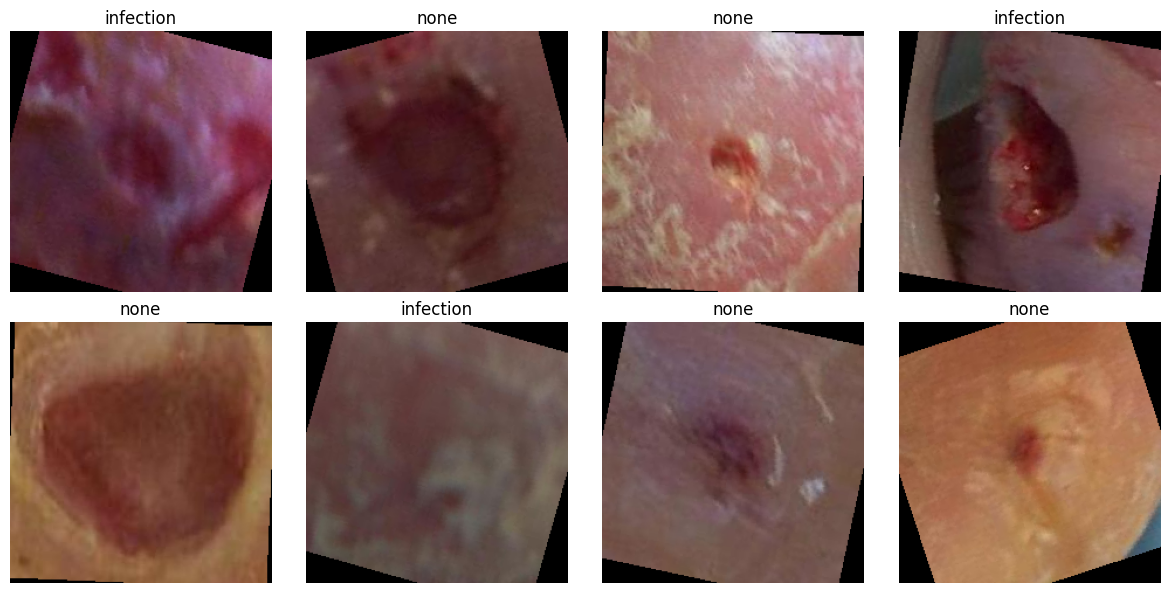

In [30]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(2,4, figsize=(12,6))

for i, ax in enumerate(axes.flat):
    img = images[i] * std + mean
    img = img.permute(1,2,0).numpy()

    ax.imshow(img)
    ax.set_title(class_names[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [31]:
model = models.efficientnet_b3(
    weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    4
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 145MB/s] 


In [32]:
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [33]:
labels = []

for _, y in train_dataset:
    labels.append(y)

labels = np.array(labels)

class_counts = np.bincount(labels, minlength=4)
print(class_counts)

[2297 2299  204  559]


In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [35]:
def train_one_epoch(model, dataloader):
    losses = MeanMetric().to(device)
    acc = Accuracy(task="multiclass", num_classes=4).to(device)

    model.train()

    for X, Y in tqdm(dataloader):
        X = X.to(device)
        Y = Y.to(device)

        preds = model(X)
        loss = criterion(preds, Y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = preds.argmax(dim=1)

        losses.update(loss, X.size(0))
        acc.update(preds, Y)

    return losses.compute().item(), acc.compute().item()

In [36]:
def validation_one_epoch(model, dataloader):
    losses = MeanMetric().to(device)
    acc = Accuracy(task="multiclass", num_classes=4).to(device)

    model.eval()

    with torch.no_grad():
        for X, Y in tqdm(dataloader):
            X = X.to(device)
            Y = Y.to(device)

            preds = model(X)
            loss = criterion(preds, Y)

            preds = preds.argmax(dim=1)

            losses.update(loss, X.size(0))
            acc.update(preds, Y)

    return losses.compute().item(), acc.compute().item()

In [37]:
history = pd.DataFrame()
best_val_acc = 0.0
best_epoch = 0

epochs = 100
patience = 8
epochs_no_improve = 0
min_delta = 0.0001

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.1,
    patience=5
)

for i in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validation_one_epoch(model, val_loader)

    scheduler.step(val_acc)

    if val_acc > best_val_acc + min_delta:
        best_val_acc = val_acc
        best_epoch = i + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_efficientnetb3_baseline.pth")
    else:
        epochs_no_improve += 1

    statistics = pd.DataFrame({
        "epoch": [i + 1],
        "train_loss": [train_loss],
        "train_acc": [train_acc],
        "val_loss": [val_loss],
        "val_acc": [val_acc],
        "learning_rate": [optimizer.param_groups[0]["lr"]]
    })

    history = pd.concat([history, statistics], ignore_index=True)

    print(statistics.to_dict(orient="records")[0])

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {i + 1}")
        break

print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_acc)

100%|██████████| 38/38 [00:06<00:00,  5.69it/s]


{'epoch': 1, 'train_loss': 0.7994018793106079, 'train_acc': 0.6424705982208252, 'val_loss': 0.6981999278068542, 'val_acc': 0.6728187799453735, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:02<00:00, 13.37it/s]


{'epoch': 2, 'train_loss': 0.6838473081588745, 'train_acc': 0.7021832466125488, 'val_loss': 0.6452361345291138, 'val_acc': 0.7197986841201782, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:02<00:00, 13.65it/s]


...

{'epoch': 50, 'train_loss': 0.04656769335269928, 'train_acc': 0.9848852157592773, 'val_loss': 0.3695438504219055, 'val_acc': 0.8892617225646973, 'learning_rate': 1e-05}


100%|██████████| 38/38 [00:02<00:00, 13.84it/s]


{'epoch': 51, 'train_loss': 0.04073973000049591, 'train_acc': 0.9852584600448608, 'val_loss': 0.3783375322818756, 'val_acc': 0.8909395933151245, 'learning_rate': 1e-05}


100%|██████████| 38/38 [00:02<00:00, 14.17it/s]

{'epoch': 52, 'train_loss': 0.03682022914290428, 'train_acc': 0.9882440567016602, 'val_loss': 0.35351282358169556, 'val_acc': 0.8926174640655518, 'learning_rate': 1e-05}
Early stopping at epoch 52
Best epoch: 44
Best validation accuracy: 0.9043624401092529


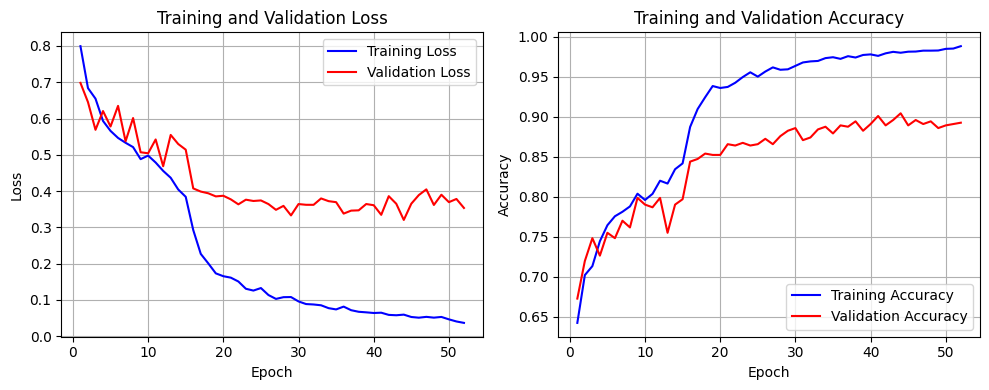

In [38]:
plt.figure(figsize=(10, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history["epoch"], history["train_loss"], label="Training Loss", color="blue")
plt.plot(history["epoch"], history["val_loss"], label="Validation Loss", color="red")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history["epoch"], history["train_acc"], label="Training Accuracy", color="blue")
plt.plot(history["epoch"], history["val_acc"], label="Validation Accuracy", color="red")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [39]:
model.load_state_dict(torch.load("best_efficientnetb3_baseline.pth", map_location=device))
model.to(device)
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [40]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    classification_report
)
import torch.nn.functional as F

model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for X, Y in val_loader:
        X = X.to(device)
        Y = Y.to(device)

        outputs = model(X)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(Y.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

In [41]:
class_names = ["none", "infection", "ischaemia", "both"]

macro_f1 = f1_score(all_labels, all_preds, average="macro")
class_f1 = f1_score(all_labels, all_preds, average=None)

macro_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

micro_f1 = f1_score(all_labels, all_preds, average="micro")


macro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
micro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="micro")

print("Macro F1:", macro_f1)
print("Control F1:", class_f1[0])
print("Infection F1:", class_f1[1])
print("Ischaemia F1:", class_f1[2])
print("Both F1:", class_f1[3])
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Micro F1:", micro_f1)
print("Micro AUC:", micro_auc)
print("Macro AUC:", macro_auc)

Macro F1: 0.9245053090468343
Control F1: 0.8932038834951457
Infection F1: 0.8958742632612967
Ischaemia F1: 0.9333333333333333
Both F1: 0.975609756097561
Macro Precision: 0.9309882918222192
Macro Recall: 0.9183427995146165
Micro F1: 0.9043624161073825
Micro AUC: 0.9882400192183535
Macro AUC: 0.9845970185929848


In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

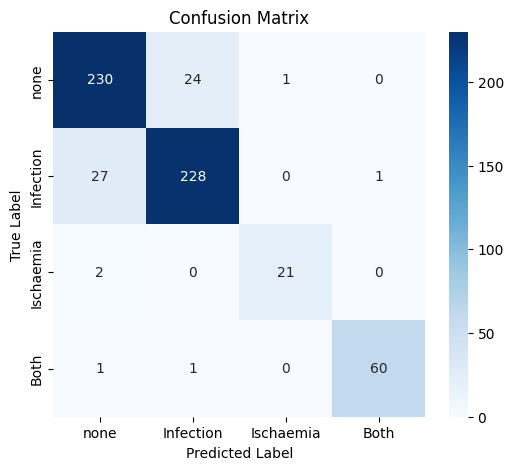

In [43]:
cm = confusion_matrix(all_labels, all_preds)

classes = ["none", "Infection", "Ischaemia", "Both"]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

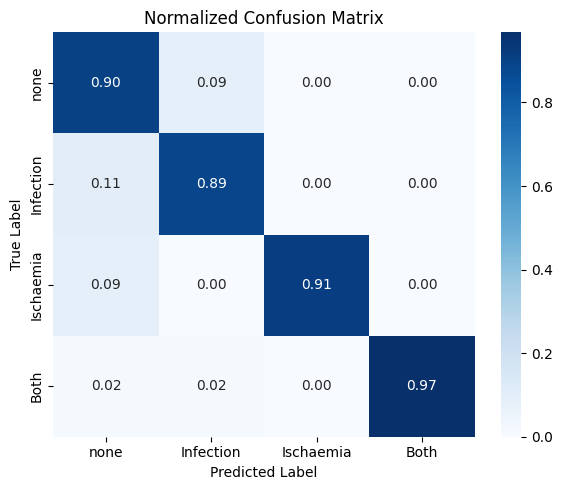

In [44]:
cm = confusion_matrix(
    all_labels,
    all_preds,
    normalize="true"
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["none","Infection","Ischaemia","Both"],
    yticklabels=["none","Infection","Ischaemia","Both"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

In [45]:
class DFUTestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.image_names = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        image_path = os.path.join(self.image_dir, image_name)

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, image_name

In [46]:
official_test_dataset = DFUTestDataset(
    test_image_dir,
    transform=test_transform
)

official_test_loader = DataLoader(
    official_test_dataset,
    batch_size=32,
    shuffle=False
)

print(len(official_test_dataset))

5734


In [47]:
model.load_state_dict(
    torch.load(
        "best_efficientnetb3_baseline.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [48]:
image_names = []
predicted_classes = []
probabilities = []

with torch.no_grad():
    for X, filenames in official_test_loader:
        X = X.to(device)

        outputs = model(X)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        image_names.extend(filenames)
        predicted_classes.extend(preds.cpu().numpy())
        probabilities.extend(probs.cpu().numpy())

probabilities = np.array(probabilities)

In [49]:
submission_df = pd.DataFrame({
    "image": image_names,
    "none": probabilities[:, 0],
    "infection": probabilities[:, 1],
    "ischaemia": probabilities[:, 2],
    "both": probabilities[:, 3]
})

submission_df.to_csv("efficientnetb3_baselinefinal_submission.csv", index=False)

submission_df.head()

,image,none,infection,ischaemia,both
0,501000.jpg,0.000053,0.993119,2.046916e-06,6.825344e-03
1,501001.jpg,0.000180,0.000003,1.506087e-01,8.492090e-01
2,501002.jpg,0.025463,0.974537,5.572543e-08,3.262122e-09
3,501003.jpg,0.987829,0.012171,2.157003e-08,1.009107e-10
4,501004.jpg,0.000043,0.045581,9.444957e-01,9.880602e-03


In [50]:
print(submission_df.shape)
print(submission_df.columns)
print(submission_df.head())
print(submission_df[["none", "infection", "ischaemia", "both"]].sum(axis=1).head())

(5734, 5)
Index(['image', 'none', 'infection', 'ischaemia', 'both'], dtype='object')
        image      none  infection     ischaemia          both
0  501000.jpg  0.000053   0.993119  2.046916e-06  6.825344e-03
1  501001.jpg  0.000180   0.000003  1.506087e-01  8.492090e-01
2  501002.jpg  0.025463   0.974537  5.572543e-08  3.262122e-09
3  501003.jpg  0.987829   0.012171  2.157003e-08  1.009107e-10
4  501004.jpg  0.000043   0.045581  9.444957e-01  9.880602e-03
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
dtype: float32


In [51]:
print(submission_df.isnull().sum())
print(submission_df["image"].duplicated().sum())

image        0
none         0
infection    0
ischaemia    0
both         0
dtype: int64
0


In [52]:
predicted_labels = np.argmax(
    submission_df[
        ["none", "infection", "ischaemia", "both"]
    ].values,
    axis=1
)

unique, counts = np.unique(
    predicted_labels,
    return_counts=True
)

for label, count in zip(unique, counts):
    print(class_names[label], count)

none 3154
infection 1830
ischaemia 427
both 323


In [53]:
submission_df.to_csv(
    "/kaggle/working/efficientnetb3_baselinefinal_submission.csv",
    index=False
)

In [54]:
print(os.path.exists(
    "/kaggle/working/efficientnetb3_baselinefinal_submission.csv"
))

True


# Pseudo Labelling

In [55]:
import os

checkpoint_path = "/kaggle/working/best_efficientnetb3_baseline.pth"

print(os.path.exists(checkpoint_path))

True


In [56]:
from torchvision import models
import torch

teacher_model = models.efficientnet_b3(weights=None)

teacher_model.classifier[1] = nn.Linear(
    teacher_model.classifier[1].in_features,
    4
)

teacher_model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

teacher_model = teacher_model.to(device)
teacher_model.eval()

print("EfficientNet-B3 teacher loaded successfully.")

EfficientNet-B3 teacher loaded successfully.


In [57]:
print(type(teacher_model))
print(teacher_model.classifier[1])

<class 'torchvision.models.efficientnet.EfficientNet'>
Linear(in_features=1536, out_features=4, bias=True)


In [58]:
label_columns = [
    "none",
    "infection",
    "ischaemia",
    "both"
]

class_names = label_columns

unlabelled_df = train_df[
    train_df[label_columns].isna().all(axis=1)
][["image"]].copy().reset_index(drop=True)

print("Unlabelled images:", len(unlabelled_df))

assert len(unlabelled_df) == 3994

Unlabelled images: 3994


In [59]:
from pathlib import Path

image_dir = Path(
    "/kaggle/input/datasets/daphn3/dfuc2021/"
    "DFU/DFUC2021_train/images"
)

In [60]:
missing_images = [
    filename
    for filename in unlabelled_df["image"]
    if not (image_dir / filename).exists()
]

print("Missing images:", len(missing_images))

assert len(missing_images) == 0

Missing images: 0


In [61]:
pseudo_transform = test_transform

In [62]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader


class UnlabelledDFUDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        filename = self.dataframe.iloc[index]["image"]
        image_path = self.image_dir / filename

        with Image.open(image_path) as image:
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, filename

In [63]:
unlabelled_dataset = UnlabelledDFUDataset(
    dataframe=unlabelled_df,
    image_dir=image_dir,
    transform=pseudo_transform
)

unlabelled_loader = DataLoader(
    unlabelled_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Dataset size:", len(unlabelled_dataset))
print("Number of batches:", len(unlabelled_loader))

Dataset size: 3994
Number of batches: 125


In [64]:
pseudo_label_records = []

teacher_model.eval()

with torch.inference_mode():
    for images, filenames in unlabelled_loader:
        images = images.to(device, non_blocking=True)

        logits = teacher_model(images)
        probabilities = torch.softmax(logits, dim=1)

        confidences, predictions = probabilities.max(dim=1)

        probabilities = probabilities.cpu().tolist()
        confidences = confidences.cpu().tolist()
        predictions = predictions.cpu().tolist()

        for filename, prediction, confidence, probs in zip(
            filenames,
            predictions,
            confidences,
            probabilities
        ):
            pseudo_label_records.append({
                "image": filename,
                "pseudo_label": prediction,
                "pseudo_class": class_names[prediction],
                "confidence": confidence,
                "prob_none": probs[0],
                "prob_infection": probs[1],
                "prob_ischaemia": probs[2],
                "prob_both": probs[3]
            })

In [65]:
pseudo_labels_df = pd.DataFrame(pseudo_label_records)

print(pseudo_labels_df.shape)

pseudo_labels_df.head()

(3994, 8)


,image,pseudo_label,pseudo_class,confidence,prob_none,prob_infection,prob_ischaemia,prob_both
0,401000.jpg,0,none,0.707760,0.707760,0.292240,6.169388e-07,2.055766e-09
1,401001.jpg,0,none,0.993099,0.993099,0.006901,5.131535e-09,6.938671e-11
2,401002.jpg,1,infection,0.952860,0.014699,0.952860,1.422164e-04,3.229883e-02
3,401003.jpg,0,none,0.990677,0.990677,0.009314,9.417733e-06,1.440275e-07
4,401004.jpg,1,infection,0.986787,0.013210,0.986787,2.362051e-06,8.444575e-07


In [66]:
probability_columns = [
    "prob_none",
    "prob_infection",
    "prob_ischaemia",
    "prob_both"
]

assert len(pseudo_labels_df) == 3994
assert pseudo_labels_df["image"].nunique() == 3994
assert pseudo_labels_df["pseudo_label"].between(0, 3).all()
assert pseudo_labels_df["confidence"].between(0, 1).all()
assert not pseudo_labels_df.isna().any().any()

probability_sums = pseudo_labels_df[
    probability_columns
].sum(axis=1)

assert np.allclose(
    probability_sums,
    1.0,
    atol=1e-5
)

print("All pseudo-label checks passed.")

All pseudo-label checks passed.


In [67]:
pseudo_labels_df.to_csv(
    "/kaggle/working/efficientnet_b3_all_pseudo_labels.csv",
    index=False
)

print("Complete B3 pseudo-label file saved.")

Complete B3 pseudo-label file saved.


In [68]:
pseudo_labels_df = pd.DataFrame(pseudo_label_records)

print(pseudo_labels_df.shape)
pseudo_labels_df.head()

(3994, 8)


,image,pseudo_label,pseudo_class,confidence,prob_none,prob_infection,prob_ischaemia,prob_both
0,401000.jpg,0,none,0.707760,0.707760,0.292240,6.169388e-07,2.055766e-09
1,401001.jpg,0,none,0.993099,0.993099,0.006901,5.131535e-09,6.938671e-11
2,401002.jpg,1,infection,0.952860,0.014699,0.952860,1.422164e-04,3.229883e-02
3,401003.jpg,0,none,0.990677,0.990677,0.009314,9.417733e-06,1.440275e-07
4,401004.jpg,1,infection,0.986787,0.013210,0.986787,2.362051e-06,8.444575e-07


## pseudo label distribution

In [69]:
distribution = (
    pseudo_labels_df["pseudo_class"]
    .value_counts()
    .reindex(class_names)
)

print(distribution)

pseudo_class
none         2100
infection    1684
ischaemia      88
both          122
Name: count, dtype: int64


In [70]:
distribution_percent = (
    pseudo_labels_df["pseudo_class"]
    .value_counts(normalize=True)
    .reindex(class_names)
    * 100
)

distribution_table = pd.DataFrame({
    "Count": distribution,
    "Percentage": distribution_percent
})

distribution_table

,Count,Percentage
pseudo_class,,
none,2100,52.578868
infection,1684,42.163245
ischaemia,88,2.203305
both,122,3.054582


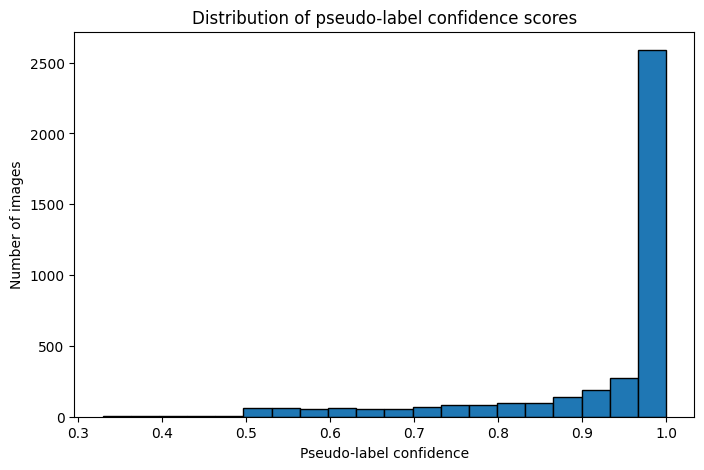

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(
    pseudo_labels_df["confidence"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Pseudo-label confidence")
plt.ylabel("Number of images")
plt.title("Distribution of pseudo-label confidence scores")
plt.show()

## confidence by predicted class

In [72]:
confidence_by_class = (
    pseudo_labels_df
    .groupby("pseudo_class")["confidence"]
    .agg(["count", "mean", "median", "min", "max"])
    .reindex(class_names)
)

confidence_by_class

,count,mean,median,min,max
pseudo_class,,,,,
none,2100,0.938826,0.996733,0.477584,1.000000
infection,1684,0.916484,0.989380,0.329382,1.000000
ischaemia,88,0.854622,0.934724,0.366298,0.999996
both,122,0.849191,0.913640,0.376570,0.999984


## pseudo labels for each threshold

In [73]:
thresholds = [
    0.80,
    0.85,
    0.90,
    0.95,
    0.99
]

threshold_results = []

for threshold in thresholds:
    retained = pseudo_labels_df[
        pseudo_labels_df["confidence"] >= threshold
    ]

    counts = (
        retained["pseudo_class"]
        .value_counts()
        .reindex(class_names, fill_value=0)
    )

    threshold_results.append({
        "Threshold": threshold,
        "Total retained": len(retained),
        "None": counts["none"],
        "Infection": counts["infection"],
        "Ischaemia": counts["ischaemia"],
        "Both": counts["both"]
    })

threshold_table = pd.DataFrame(threshold_results)

threshold_table

,Threshold,Total retained,None,Infection,Ischaemia,Both
0,0.80,3389,1841,1399,64,85
1,0.85,3246,1791,1329,52,74
2,0.90,3053,1705,1240,45,63
3,0.95,2748,1556,1101,40,51
4,0.99,2139,1250,829,27,33


## teacher confidence vs actual correctness

In [74]:
val_predictions = []

teacher_model.eval()

with torch.inference_mode():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = teacher_model(images)
        probabilities = torch.softmax(logits, dim=1)

        confidences, predictions = probabilities.max(dim=1)

        for true_label, pred_label, confidence in zip(
            labels.cpu().numpy(),
            predictions.cpu().numpy(),
            confidences.cpu().numpy()
        ):
            val_predictions.append({
                "true_label": int(true_label),
                "predicted_label": int(pred_label),
                "confidence": float(confidence),
                "correct": int(true_label == pred_label)
            })

In [75]:
val_pseudo_df = pd.DataFrame(val_predictions)

val_pseudo_df["true_class"] = val_pseudo_df["true_label"].map(
    dict(enumerate(class_names))
)

val_pseudo_df["predicted_class"] = val_pseudo_df["predicted_label"].map(
    dict(enumerate(class_names))
)

val_pseudo_df.head()

,true_label,predicted_label,confidence,correct,true_class,predicted_class
0,3,3,0.999289,1,both,both
1,1,1,0.986184,1,infection,infection
2,2,2,0.999999,1,ischaemia,ischaemia
3,0,0,0.959273,1,none,none
4,3,3,0.971276,1,both,both


In [76]:
overall_accuracy = val_pseudo_df["correct"].mean()

print(f"Overall pseudo-label accuracy: {overall_accuracy:.4f}")

Overall pseudo-label accuracy: 0.9044


In [77]:
thresholds = [0.80, 0.85, 0.90, 0.95, 0.99]

validation_threshold_results = []

for threshold in thresholds:
    retained = val_pseudo_df[
        val_pseudo_df["confidence"] >= threshold
    ]

    validation_threshold_results.append({
        "Threshold": threshold,
        "Predictions retained": len(retained),
        "Percentage retained": (
            len(retained) / len(val_pseudo_df)
        ) * 100,
        "Pseudo-label accuracy": retained["correct"].mean()
    })

validation_accuracy_table = pd.DataFrame(
    validation_threshold_results
)

validation_accuracy_table

,Threshold,Predictions retained,Percentage retained,Pseudo-label accuracy
0,0.80,548,91.946309,0.927007
1,0.85,530,88.926174,0.945283
2,0.90,512,85.906040,0.951172
3,0.95,487,81.711409,0.958932
4,0.99,413,69.295302,0.973366


In [78]:
class_accuracy = (
    val_pseudo_df
    .groupby("predicted_class")
    .agg(
        predictions=("correct", "size"),
        accuracy=("correct", "mean"),
        mean_confidence=("confidence", "mean")
    )
    .reindex(class_names)
)

class_accuracy

,predictions,accuracy,mean_confidence
predicted_class,,,
none,260,0.884615,0.954709
infection,253,0.901186,0.953474
ischaemia,22,0.954545,0.979024
both,61,0.983607,0.978127


In [79]:
thresholds = [0.80, 0.85, 0.90, 0.95, 0.99]

filtered_pseudo_dfs = {}

for threshold in thresholds:
    
    filtered_df = pseudo_labels_df[
        pseudo_labels_df["confidence"] >= threshold
    ].copy()

    # Create the label column required for training
    filtered_df["label"] = filtered_df["pseudo_label"].astype(int)

    filtered_pseudo_dfs[threshold] = filtered_df

    print(
        f"Threshold {threshold}: "
        f"{len(filtered_df)} pseudo-labelled images"
    )

Threshold 0.8: 3389 pseudo-labelled images
Threshold 0.85: 3246 pseudo-labelled images
Threshold 0.9: 3053 pseudo-labelled images
Threshold 0.95: 2748 pseudo-labelled images
Threshold 0.99: 2139 pseudo-labelled images


In [80]:
filtered_pseudo_dfs[0.80][
    ["image", "pseudo_label", "pseudo_class", "confidence", "label"]
].head()

,image,pseudo_label,pseudo_class,confidence,label
1,401001.jpg,0,none,0.993099,0
2,401002.jpg,1,infection,0.952860,1
3,401003.jpg,0,none,0.990677,0
4,401004.jpg,1,infection,0.986787,1
5,401005.jpg,2,ischaemia,0.879232,2


# combine each pseudo label threshold set with original labelled training split

In [81]:
labelled_train_df = train_split_df[
    ["image", "label"]
].copy()

print("Original labelled training images:", len(labelled_train_df))

Original labelled training images: 5359


In [82]:
combined_dfs = {}

for threshold in thresholds:

    pseudo_df = filtered_pseudo_dfs[threshold][
        ["image", "label"]
    ].copy()

    combined_df = pd.concat(
        [labelled_train_df, pseudo_df],
        ignore_index=True
    )

    combined_dfs[threshold] = combined_df

    print(
        f"Threshold {threshold}: "
        f"{len(labelled_train_df)} labelled + "
        f"{len(pseudo_df)} pseudo-labelled = "
        f"{len(combined_df)} total"
    )

Threshold 0.8: 5359 labelled + 3389 pseudo-labelled = 8748 total
Threshold 0.85: 5359 labelled + 3246 pseudo-labelled = 8605 total
Threshold 0.9: 5359 labelled + 3053 pseudo-labelled = 8412 total
Threshold 0.95: 5359 labelled + 2748 pseudo-labelled = 8107 total
Threshold 0.99: 5359 labelled + 2139 pseudo-labelled = 7498 total


In [83]:
for threshold in thresholds:

    overlap = set(
        combined_dfs[threshold]["image"]
    ).intersection(
        set(val_df["image"])
    )

    print(
        f"Threshold {threshold}: "
        f"{len(overlap)} validation images in training set"
    )

    assert len(overlap) == 0

Threshold 0.8: 0 validation images in training set
Threshold 0.85: 0 validation images in training set
Threshold 0.9: 0 validation images in training set
Threshold 0.95: 0 validation images in training set
Threshold 0.99: 0 validation images in training set


# 0.80 Threshold

In [84]:
threshold = 0.80

train_080_df = combined_dfs[threshold].copy()

train_080_dataset = DFUDataset(
    train_080_df,
    train_image_dir,
    transform=train_transform
)

train_080_loader = DataLoader(
    train_080_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("0.80 training images:", len(train_080_dataset))
print("Validation images:", len(val_dataset))

0.80 training images: 8748
Validation images: 596


In [85]:
student_080 = models.efficientnet_b3(
    weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
)

student_080.classifier[1] = nn.Linear(
    student_080.classifier[1].in_features,
    4
)

student_080 = student_080.to(device)

print("Fresh EfficientNet-B3 student created.")

Fresh EfficientNet-B3 student created.


In [86]:
criterion_080 = nn.CrossEntropyLoss()

optimizer_080 = torch.optim.Adam(
    student_080.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


In [87]:
checkpoint_080 = "/kaggle/working/best_efficientnet_b3_threshold_080.pth"

In [88]:
model = student_080
train_loader = train_080_loader

criterion = criterion_080
optimizer = optimizer_080

In [89]:
history_080 = pd.DataFrame()
best_val_acc = 0.0
best_epoch = 0

epochs = 100
patience = 8
epochs_no_improve = 0
min_delta = 0.0001

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.1,
    patience=5
)

for i in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validation_one_epoch(model, val_loader)

    scheduler.step(val_acc)

    if val_acc > best_val_acc + min_delta:
        best_val_acc = val_acc
        best_epoch = i + 1
        epochs_no_improve = 0

        torch.save(
            model.state_dict(),
            "best_efficientnetb3_threshold_080.pth"
        )

    else:
        epochs_no_improve += 1

    statistics = pd.DataFrame({
        "epoch": [i + 1],
        "train_loss": [train_loss],
        "train_acc": [train_acc],
        "val_loss": [val_loss],
        "val_acc": [val_acc],
        "learning_rate": [optimizer.param_groups[0]["lr"]]
    })

    history_080 = pd.concat(
        [history_080, statistics],
        ignore_index=True
    )

    print(statistics.to_dict(orient="records")[0])

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {i + 1}")
        break

print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_acc)

100%|██████████| 38/38 [00:03<00:00, 12.61it/s]


{'epoch': 1, 'train_loss': 0.7144995927810669, 'train_acc': 0.6810699701309204, 'val_loss': 0.8218716382980347, 'val_acc': 0.6744966506958008, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:07<00:00,  5.29it/s]


{'epoch': 2, 'train_loss': 0.6080668568611145, 'train_acc': 0.7479423880577087, 'val_loss': 0.6128689646720886, 'val_acc': 0.7214764952659607, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:12<00:00,  3.03it/s]


...

{'epoch': 56, 'train_loss': 0.05247143656015396, 'train_acc': 0.9825102686882019, 'val_loss': 0.3525731861591339, 'val_acc': 0.8892617225646973, 'learning_rate': 1.0000000000000002e-06}


100%|██████████| 38/38 [00:03<00:00, 11.54it/s]


{'epoch': 57, 'train_loss': 0.05268255993723869, 'train_acc': 0.9807956218719482, 'val_loss': 0.3211980164051056, 'val_acc': 0.8926174640655518, 'learning_rate': 1.0000000000000002e-06}


100%|██████████| 38/38 [00:03<00:00, 11.79it/s]

{'epoch': 58, 'train_loss': 0.05695011839270592, 'train_acc': 0.9812528491020203, 'val_loss': 0.3206835389137268, 'val_acc': 0.8959731459617615, 'learning_rate': 1.0000000000000002e-06}
Early stopping at epoch 58
Best epoch: 50
Best validation accuracy: 0.9043624401092529


In [90]:
model.load_state_dict(
    torch.load(
        "best_efficientnetb3_threshold_080.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

print("Best 0.80 model loaded.")

Best 0.80 model loaded.


In [91]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

all_labels = []
all_preds = []
all_probs = []

model.eval()

with torch.inference_mode():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

In [92]:
class_names = ["none", "infection", "ischaemia", "both"]

macro_f1 = f1_score(all_labels, all_preds, average="macro")
class_f1 = f1_score(all_labels, all_preds, average=None)

macro_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

micro_f1 = f1_score(all_labels, all_preds, average="micro")


macro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
micro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="micro")

print("Macro F1:", macro_f1)
print("Control F1:", class_f1[0])
print("Infection F1:", class_f1[1])
print("Ischaemia F1:", class_f1[2])
print("Both F1:", class_f1[3])
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Micro F1:", micro_f1)
print("Micro AUC:", micro_auc)
print("Macro AUC:", macro_auc)

Macro F1: 0.9131647721188823
Control F1: 0.8941176470588236
Infection F1: 0.8996138996138996
Ischaemia F1: 0.8837209302325582
Both F1: 0.9752066115702479
Macro Precision: 0.933357656039515
Macro Recall: 0.8954934392015923
Micro F1: 0.9043624161073825
Micro AUC: 0.9883854706244464
Macro AUC: 0.9846875095948499


# 0.85 threshold

In [93]:
threshold = 0.85

train_085_df = combined_dfs[threshold].copy()

train_085_dataset = DFUDataset(
    train_085_df,
    train_image_dir,
    transform=train_transform
)

train_085_loader = DataLoader(
    train_085_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("0.85 training images:", len(train_085_dataset))

0.85 training images: 8605


In [94]:
student_085 = models.efficientnet_b3(
    weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
)

student_085.classifier[1] = nn.Linear(
    student_085.classifier[1].in_features,
    4
)

student_085 = student_085.to(device)

In [95]:
model = student_085
train_loader = train_085_loader

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [96]:
history_085 = pd.DataFrame()
best_val_acc = 0.0
best_epoch = 0

epochs = 100
patience = 8
epochs_no_improve = 0
min_delta = 0.0001

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.1,
    patience=5
)

for i in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validation_one_epoch(model, val_loader)

    scheduler.step(val_acc)

    if val_acc > best_val_acc + min_delta:
        best_val_acc = val_acc
        best_epoch = i + 1
        epochs_no_improve = 0

        torch.save(
            model.state_dict(),
            "best_efficientnetb3_threshold_085.pth"
        )

    else:
        epochs_no_improve += 1

    statistics = pd.DataFrame({
        "epoch": [i + 1],
        "train_loss": [train_loss],
        "train_acc": [train_acc],
        "val_loss": [val_loss],
        "val_acc": [val_acc],
        "learning_rate": [optimizer.param_groups[0]["lr"]]
    })

    history_085 = pd.concat(
        [history_085, statistics],
        ignore_index=True
    )
    
    print(statistics.to_dict(orient="records")[0])

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {i + 1}")
        break

print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_acc)


100%|██████████| 38/38 [00:03<00:00, 11.33it/s]


{'epoch': 1, 'train_loss': 0.7179170250892639, 'train_acc': 0.67925626039505, 'val_loss': 0.6646210551261902, 'val_acc': 0.7097315192222595, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:02<00:00, 12.99it/s]


{'epoch': 2, 'train_loss': 0.6125683784484863, 'train_acc': 0.7364323139190674, 'val_loss': 0.5959656238555908, 'val_acc': 0.7348993420600891, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:03<00:00, 12.09it/s]


...

{'epoch': 45, 'train_loss': 0.06800537556409836, 'train_acc': 0.9757118225097656, 'val_loss': 0.4315977096557617, 'val_acc': 0.8775168061256409, 'learning_rate': 1e-05}


100%|██████████| 38/38 [00:05<00:00,  6.80it/s]


{'epoch': 46, 'train_loss': 0.06051774322986603, 'train_acc': 0.9775711894035339, 'val_loss': 0.42298322916030884, 'val_acc': 0.8791946172714233, 'learning_rate': 1e-05}


100%|██████████| 38/38 [00:02<00:00, 13.13it/s]

{'epoch': 47, 'train_loss': 0.06106967106461525, 'train_acc': 0.9786170721054077, 'val_loss': 0.43380147218704224, 'val_acc': 0.8842281699180603, 'learning_rate': 1e-05}
Early stopping at epoch 47
Best epoch: 39
Best validation accuracy: 0.8976510167121887


In [97]:
model.load_state_dict(
    torch.load(
        "best_efficientnetb3_threshold_085.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

print("Best 0.85 model loaded.")

Best 0.85 model loaded.


In [98]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

all_labels = []
all_preds = []
all_probs = []

model.eval()

with torch.inference_mode():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

In [99]:
class_names = ["none", "infection", "ischaemia", "both"]

macro_f1 = f1_score(all_labels, all_preds, average="macro")
class_f1 = f1_score(all_labels, all_preds, average=None)

macro_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

micro_f1 = f1_score(all_labels, all_preds, average="micro")


macro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
micro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="micro")

print("Macro F1:", macro_f1)
print("Control F1:", class_f1[0])
print("Infection F1:", class_f1[1])
print("Ischaemia F1:", class_f1[2])
print("Both F1:", class_f1[3])
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Micro F1:", micro_f1)
print("Micro AUC:", micro_auc)
print("Macro AUC:", macro_auc)

Macro F1: 0.9120439691027926
Control F1: 0.8888888888888888
Infection F1: 0.8901960784313725
Ischaemia F1: 0.9090909090909091
Both F1: 0.96
Macro Precision: 0.9205459055990095
Macro Recall: 0.9045358874834997
Micro F1: 0.8976510067114094
Micro AUC: 0.9821845487440506
Macro AUC: 0.9774024704896291


# 0.90 threshold

In [100]:
threshold = 0.90

train_090_df = combined_dfs[threshold].copy()

train_090_dataset = DFUDataset(
    train_090_df,
    train_image_dir,
    transform=train_transform
)

train_090_loader = DataLoader(
    train_090_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("0.90 training images:", len(train_090_dataset))

0.90 training images: 8412


In [101]:
student_090 = models.efficientnet_b3(
    weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
)

student_090.classifier[1] = nn.Linear(
    student_090.classifier[1].in_features,
    4
)

student_090 = student_090.to(device)

In [102]:
model = student_090
train_loader = train_090_loader

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [103]:
history_090 = pd.DataFrame()
best_val_acc = 0.0
best_epoch = 0

epochs = 100
patience = 8
epochs_no_improve = 0
min_delta = 0.0001

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.1,
    patience=5
)

for i in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validation_one_epoch(model, val_loader)

    scheduler.step(val_acc)

    if val_acc > best_val_acc + min_delta:
        best_val_acc = val_acc
        best_epoch = i + 1
        epochs_no_improve = 0

        torch.save(
            model.state_dict(),
            "best_efficientnetb3_threshold_090.pth"
        )

    else:
        epochs_no_improve += 1

    statistics = pd.DataFrame({
        "epoch": [i + 1],
        "train_loss": [train_loss],
        "train_acc": [train_acc],
        "val_loss": [val_loss],
        "val_acc": [val_acc],
        "learning_rate": [optimizer.param_groups[0]["lr"]]
    })

    history_090 = pd.concat(
        [history_090, statistics],
        ignore_index=True
    )
    
    print(statistics.to_dict(orient="records")[0])

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {i + 1}")
        break

print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_acc)

100%|██████████| 38/38 [00:02<00:00, 13.35it/s]


{'epoch': 1, 'train_loss': 0.7031609416007996, 'train_acc': 0.695435106754303, 'val_loss': 0.6169187426567078, 'val_acc': 0.7147650718688965, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:02<00:00, 13.83it/s]


{'epoch': 2, 'train_loss': 0.5966842174530029, 'train_acc': 0.746433675289154, 'val_loss': 0.6487001776695251, 'val_acc': 0.708053708076477, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:02<00:00, 13.53it/s]


...

{'epoch': 41, 'train_loss': 0.06824983656406403, 'train_acc': 0.9771754741668701, 'val_loss': 0.4059165418148041, 'val_acc': 0.9010066986083984, 'learning_rate': 1e-05}


100%|██████████| 38/38 [00:02<00:00, 14.21it/s]


{'epoch': 42, 'train_loss': 0.05345289036631584, 'train_acc': 0.9812173247337341, 'val_loss': 0.4120026230812073, 'val_acc': 0.8976510167121887, 'learning_rate': 1e-05}


100%|██████████| 38/38 [00:02<00:00, 13.75it/s]

{'epoch': 43, 'train_loss': 0.05582309886813164, 'train_acc': 0.9810984134674072, 'val_loss': 0.40847817063331604, 'val_acc': 0.899328887462616, 'learning_rate': 1e-05}
Early stopping at epoch 43
Best epoch: 35
Best validation accuracy: 0.9010066986083984


In [104]:
model.load_state_dict(
    torch.load(
        "best_efficientnetb3_threshold_090.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

print("Best 0.90 model loaded.")

Best 0.90 model loaded.


In [105]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

all_labels = []
all_preds = []
all_probs = []

model.eval()

with torch.inference_mode():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

In [106]:
class_names = ["none", "infection", "ischaemia", "both"]

macro_f1 = f1_score(all_labels, all_preds, average="macro")
class_f1 = f1_score(all_labels, all_preds, average=None)

macro_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

micro_f1 = f1_score(all_labels, all_preds, average="micro")


macro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
micro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="micro")

print("Macro F1:", macro_f1)
print("Control F1:", class_f1[0])
print("Infection F1:", class_f1[1])
print("Ischaemia F1:", class_f1[2])
print("Both F1:", class_f1[3])
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Micro F1:", micro_f1)
print("Micro AUC:", micro_auc)
print("Macro AUC:", macro_auc)

Macro F1: 0.8987969716232955
Control F1: 0.903954802259887
Infection F1: 0.8930041152263375
Ischaemia F1: 0.8627450980392157
Both F1: 0.9354838709677419
Macro Precision: 0.8835604087357243
Macro Recall: 0.920209582671603
Micro F1: 0.9010067114093959
Micro AUC: 0.9804433546536941
Macro AUC: 0.9789010311752444


# 0.95 Threshold

In [107]:
threshold = 0.95

train_095_df = combined_dfs[threshold].copy()

train_095_dataset = DFUDataset(
    train_095_df,
    train_image_dir,
    transform=train_transform
)

train_095_loader = DataLoader(
    train_095_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("0.95 training images:", len(train_095_dataset))

0.95 training images: 8107


In [108]:
student_095 = models.efficientnet_b3(
    weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
)

student_095.classifier[1] = nn.Linear(
    student_095.classifier[1].in_features,
    4
)

student_095 = student_095.to(device)

In [109]:
model = student_095
train_loader = train_095_loader

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [110]:
history_095 = pd.DataFrame()
best_val_acc = 0.0
best_epoch = 0

epochs = 100
patience = 8
epochs_no_improve = 0
min_delta = 0.0001

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.1,
    patience=5
)

for i in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validation_one_epoch(model, val_loader)

    scheduler.step(val_acc)

    if val_acc > best_val_acc + min_delta:
        best_val_acc = val_acc
        best_epoch = i + 1
        epochs_no_improve = 0

        torch.save(
            model.state_dict(),
            "best_efficientnetb3_threshold_095.pth"
        )

    else:
        epochs_no_improve += 1

    statistics = pd.DataFrame({
        "epoch": [i + 1],
        "train_loss": [train_loss],
        "train_acc": [train_acc],
        "val_loss": [val_loss],
        "val_acc": [val_acc],
        "learning_rate": [optimizer.param_groups[0]["lr"]]
    })

    history_095 = pd.concat(
        [history_095, statistics],
        ignore_index=True
    )
    
    print(statistics.to_dict(orient="records")[0])

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {i + 1}")
        break

print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_acc)

100%|██████████| 38/38 [00:02<00:00, 13.83it/s]


{'epoch': 1, 'train_loss': 0.7054588794708252, 'train_acc': 0.6940914988517761, 'val_loss': 0.7080888748168945, 'val_acc': 0.7030201554298401, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:02<00:00, 13.86it/s]


{'epoch': 2, 'train_loss': 0.5891403555870056, 'train_acc': 0.7593438029289246, 'val_loss': 0.646817684173584, 'val_acc': 0.7281879186630249, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:02<00:00, 14.05it/s]


...

{'epoch': 37, 'train_loss': 0.07637569308280945, 'train_acc': 0.9723695516586304, 'val_loss': 0.4389984905719757, 'val_acc': 0.8859060406684875, 'learning_rate': 1e-05}


100%|██████████| 38/38 [00:02<00:00, 14.20it/s]


{'epoch': 38, 'train_loss': 0.06420253962278366, 'train_acc': 0.9777969717979431, 'val_loss': 0.4378948211669922, 'val_acc': 0.8825503587722778, 'learning_rate': 1e-05}


100%|██████████| 38/38 [00:02<00:00, 14.15it/s]

{'epoch': 39, 'train_loss': 0.06223883107304573, 'train_acc': 0.9771802425384521, 'val_loss': 0.43065115809440613, 'val_acc': 0.8825503587722778, 'learning_rate': 1e-05}
Early stopping at epoch 39
Best epoch: 31
Best validation accuracy: 0.8859060406684875


In [111]:
model.load_state_dict(
    torch.load(
        "best_efficientnetb3_threshold_095.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

print("Best 0.95 model loaded.")

Best 0.95 model loaded.


In [112]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

all_labels = []
all_preds = []
all_probs = []

model.eval()

with torch.inference_mode():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

In [113]:
class_names = ["none", "infection", "ischaemia", "both"]

macro_f1 = f1_score(all_labels, all_preds, average="macro")
class_f1 = f1_score(all_labels, all_preds, average=None)

macro_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

micro_f1 = f1_score(all_labels, all_preds, average="micro")


macro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
micro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="micro")

print("Macro F1:", macro_f1)
print("Control F1:", class_f1[0])
print("Infection F1:", class_f1[1])
print("Ischaemia F1:", class_f1[2])
print("Both F1:", class_f1[3])
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Micro F1:", micro_f1)
print("Micro AUC:", micro_auc)
print("Macro AUC:", macro_auc)

Macro F1: 0.8955962591330813
Control F1: 0.8845401174168297
Infection F1: 0.8762278978388998
Ischaemia F1: 0.8936170212765957
Both F1: 0.928
Macro Precision: 0.8899675863840265
Macro Recall: 0.9014739022581333
Micro F1: 0.8859060402684564
Micro AUC: 0.9802322155158176
Macro AUC: 0.977408635924187


# 0.99 threshold

In [114]:
threshold = 0.99

train_099_df = combined_dfs[threshold].copy()

train_099_dataset = DFUDataset(
    train_099_df,
    train_image_dir,
    transform=train_transform
)

train_099_loader = DataLoader(
    train_099_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("0.99 training images:", len(train_099_dataset))

0.99 training images: 7498


In [115]:
student_099 = models.efficientnet_b3(
    weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
)

student_099.classifier[1] = nn.Linear(
    student_099.classifier[1].in_features,
    4
)

student_099 = student_099.to(device)

In [116]:
model = student_099
train_loader = train_099_loader

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [117]:
history_099 = pd.DataFrame()
best_val_acc = 0.0
best_epoch = 0

epochs = 100
patience = 8
epochs_no_improve = 0
min_delta = 0.0001

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.1,
    patience=5
)

for i in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validation_one_epoch(model, val_loader)

    scheduler.step(val_acc)

    if val_acc > best_val_acc + min_delta:
        best_val_acc = val_acc
        best_epoch = i + 1
        epochs_no_improve = 0

        torch.save(
            model.state_dict(),
            "best_efficientnetb3_threshold_099.pth"
        )

    else:
        epochs_no_improve += 1

    statistics = pd.DataFrame({
        "epoch": [i + 1],
        "train_loss": [train_loss],
        "train_acc": [train_acc],
        "val_loss": [val_loss],
        "val_acc": [val_acc],
        "learning_rate": [optimizer.param_groups[0]["lr"]]
    })

    history_099 = pd.concat(
        [history_099, statistics],
        ignore_index=True
    )
        

    print(statistics.to_dict(orient="records")[0])

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {i + 1}")
        break

print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_acc)

100%|██████████| 38/38 [00:02<00:00, 13.81it/s]


{'epoch': 1, 'train_loss': 0.7071924209594727, 'train_acc': 0.6949853301048279, 'val_loss': 0.6907628178596497, 'val_acc': 0.7030201554298401, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:02<00:00, 13.90it/s]


{'epoch': 2, 'train_loss': 0.5824994444847107, 'train_acc': 0.7598026394844055, 'val_loss': 0.632524847984314, 'val_acc': 0.7399328947067261, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:02<00:00, 13.84it/s]


...

{'epoch': 53, 'train_loss': 0.040483929216861725, 'train_acc': 0.9855961799621582, 'val_loss': 0.3951370418071747, 'val_acc': 0.8859060406684875, 'learning_rate': 1e-05}


100%|██████████| 38/38 [00:02<00:00, 13.52it/s]


{'epoch': 54, 'train_loss': 0.03600022941827774, 'train_acc': 0.9881301522254944, 'val_loss': 0.36402374505996704, 'val_acc': 0.9010066986083984, 'learning_rate': 1e-05}


100%|██████████| 38/38 [00:02<00:00, 14.07it/s]

{'epoch': 55, 'train_loss': 0.03211639076471329, 'train_acc': 0.9898639917373657, 'val_loss': 0.3728344440460205, 'val_acc': 0.899328887462616, 'learning_rate': 1e-05}
Early stopping at epoch 55
Best epoch: 47
Best validation accuracy: 0.9043624401092529


In [118]:
model.load_state_dict(
    torch.load(
        "best_efficientnetb3_threshold_099.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

print("Best 0.99 model loaded.")

Best 0.99 model loaded.


In [119]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

all_labels = []
all_preds = []
all_probs = []

model.eval()

with torch.inference_mode():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

In [120]:
class_names = ["none", "infection", "ischaemia", "both"]

macro_f1 = f1_score(all_labels, all_preds, average="macro")
class_f1 = f1_score(all_labels, all_preds, average=None)

macro_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

micro_f1 = f1_score(all_labels, all_preds, average="micro")


macro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
micro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="micro")

print("Macro F1:", macro_f1)
print("Control F1:", class_f1[0])
print("Infection F1:", class_f1[1])
print("Ischaemia F1:", class_f1[2])
print("Both F1:", class_f1[3])
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Micro F1:", micro_f1)
print("Micro AUC:", micro_auc)
print("Macro AUC:", macro_auc)

Macro F1: 0.9167285289997176
Control F1: 0.8994082840236687
Infection F1: 0.8966861598440545
Ischaemia F1: 0.92
Both F1: 0.9508196721311475
Macro Precision: 0.9045555143804171
Macro Recall: 0.9320097545066414
Micro F1: 0.9043624161073825
Micro AUC: 0.9851245439394622
Macro AUC: 0.9826891335030976


# 0.97 threshold

In [121]:
threshold = 0.97

filtered_097_df = pseudo_labels_df[
    pseudo_labels_df["confidence"] >= threshold
].copy()

filtered_097_df["label"] = filtered_097_df["pseudo_label"].astype(int)

print("0.97 pseudo-labelled images:", len(filtered_097_df))

0.97 pseudo-labelled images: 2554


In [122]:
train_097_df = pd.concat(
    [
        labelled_train_df,
        filtered_097_df[["image", "label"]]
    ],
    ignore_index=True
)

print("0.97 total training images:", len(train_097_df))

0.97 total training images: 7913


In [123]:
overlap = set(train_097_df["image"]).intersection(
    set(val_df["image"])
)

print("Validation images in training set:", len(overlap))

assert len(overlap) == 0

Validation images in training set: 0


In [124]:
train_097_dataset = DFUDataset(
    train_097_df,
    train_image_dir,
    transform=train_transform
)

train_097_loader = DataLoader(
    train_097_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [125]:
student_097 = models.efficientnet_b3(
    weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
)

student_097.classifier[1] = nn.Linear(
    student_097.classifier[1].in_features,
    4
)

student_097 = student_097.to(device)

In [126]:
history_097 = pd.DataFrame()
best_val_acc = 0.0
best_epoch = 0

epochs = 100
patience = 8
epochs_no_improve = 0
min_delta = 0.0001

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.1,
    patience=5
)

for i in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validation_one_epoch(model, val_loader)

    scheduler.step(val_acc)

    if val_acc > best_val_acc + min_delta:
        best_val_acc = val_acc
        best_epoch = i + 1
        epochs_no_improve = 0

        torch.save(
            model.state_dict(),
            "best_efficientnetb3_threshold_097.pth"
        )

    else:
        epochs_no_improve += 1

    statistics = pd.DataFrame({
        "epoch": [i + 1],
        "train_loss": [train_loss],
        "train_acc": [train_acc],
        "val_loss": [val_loss],
        "val_acc": [val_acc],
        "learning_rate": [optimizer.param_groups[0]["lr"]]
    })

    history_097 = pd.concat(
        [history_097, statistics],
        ignore_index=True
    )
    
    print(statistics.to_dict(orient="records")[0])

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {i + 1}")
        break

print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_acc)

100%|██████████| 38/38 [00:02<00:00, 14.15it/s]


{'epoch': 1, 'train_loss': 0.04203492030501366, 'train_acc': 0.9863963723182678, 'val_loss': 0.35895147919654846, 'val_acc': 0.9026845693588257, 'learning_rate': 1e-05}


100%|██████████| 38/38 [00:02<00:00, 14.07it/s]


{'epoch': 2, 'train_loss': 0.038076333701610565, 'train_acc': 0.9869298338890076, 'val_loss': 0.38064149022102356, 'val_acc': 0.8976510167121887, 'learning_rate': 1e-05}


100%|██████████| 38/38 [00:02<00:00, 13.71it/s]


...

{'epoch': 12, 'train_loss': 0.04160323366522789, 'train_acc': 0.9853294491767883, 'val_loss': 0.3700856864452362, 'val_acc': 0.9010066986083984, 'learning_rate': 1.0000000000000002e-06}


100%|██████████| 38/38 [00:03<00:00, 11.67it/s]


{'epoch': 13, 'train_loss': 0.03942763805389404, 'train_acc': 0.9879968166351318, 'val_loss': 0.3579808175563812, 'val_acc': 0.9010066986083984, 'learning_rate': 1.0000000000000002e-06}


100%|██████████| 38/38 [00:02<00:00, 13.84it/s]

{'epoch': 14, 'train_loss': 0.04153807833790779, 'train_acc': 0.9866631031036377, 'val_loss': 0.36649906635284424, 'val_acc': 0.9010066986083984, 'learning_rate': 1.0000000000000002e-06}
Early stopping at epoch 14
Best epoch: 6
Best validation accuracy: 0.9060402512550354


In [127]:
model.load_state_dict(
    torch.load(
        "best_efficientnetb3_threshold_097.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

print("Best 0.97 model loaded.")

Best 0.97 model loaded.


In [128]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

all_labels = []
all_preds = []
all_probs = []

model.eval()

with torch.inference_mode():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

In [129]:
class_names = ["none", "infection", "ischaemia", "both"]

macro_f1 = f1_score(all_labels, all_preds, average="macro")
class_f1 = f1_score(all_labels, all_preds, average=None)

macro_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

micro_f1 = f1_score(all_labels, all_preds, average="micro")


macro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
micro_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="micro")

print("Macro F1:", macro_f1)
print("Control F1:", class_f1[0])
print("Infection F1:", class_f1[1])
print("Ischaemia F1:", class_f1[2])
print("Both F1:", class_f1[3])
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Micro F1:", micro_f1)
print("Micro AUC:", micro_auc)
print("Macro AUC:", macro_auc)

Macro F1: 0.9245038835698748
Control F1: 0.8946322067594433
Infection F1: 0.9
Ischaemia F1: 0.9361702127659575
Both F1: 0.9672131147540983
Macro Precision: 0.9234054252199413
Macro Recall: 0.926137520883178
Micro F1: 0.9060402684563759
Micro AUC: 0.9850860696965602
Macro AUC: 0.9822097103106006
